# PHISHING SITE DETECTOR👨‍💻

In [1]:
#import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:
#load the dtaset
df = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

### Label 1 corresponds to a legitimate URL, label 0 to a phishing URL

In [3]:
df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [4]:
df.isnull().sum()
df.shape
#df["label"].value_counts()

(235795, 56)

In [5]:
#feature engineering
df["suspicious_character_density"] = (df["NoOfOtherSpecialCharsInURL"] + df["NoOfObfuscatedChar"]) / df["URLLength"]

In [6]:
drop_cols = [
    'FILENAME',
    'URLSimilarityIndex',
    'HasTitle',
    'Title', 
    'DomainTitleMatchScore',
    'URLTitleMatchScore',
    'NoOfLettersInURL',
    'suspicious_character_density',
    'URL',
    'Domain',
    'TLD'
   
]

df_clean = df.drop(drop_cols, axis=1)

In [7]:
df.columns.astype(object)

Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       'NoOfEmptyRef', 'NoOf

In [8]:
target_corr = df_clean.drop([ 'label'], axis=1).corr().abs()
target_corr = df_clean.drop(['label'], axis=1)\
                      .corrwith(df_clean['label'])\
                      .abs()\
                      .sort_values(ascending=False)

print(target_corr.head(15))

HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
HasSubmitButton          0.578561
IsResponsive             0.548608
SpacialCharRatioInURL    0.533537
HasHiddenFields          0.507731
HasFavicon               0.493711
URLCharProb              0.469749
CharContinuationRate     0.467735
DegitRatioInURL          0.432032
Robots                   0.392620
NoOfJS                   0.373500
LetterRatioInURL         0.367794
dtype: float64


In [9]:
corr_matrix = df_clean.drop(['label'], axis=1).corr().abs()

# Upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 0.85 se zyada wale pairs
high_corr = upper.stack().reset_index()
high_corr.columns = ['Feature1', 'Feature2', 'Correlation']
high_corr = high_corr[high_corr['Correlation'] > 0.80].sort_values('Correlation', ascending=False)

print(high_corr)

            Feature1         Feature2  Correlation
11         URLLength  NoOfDegitsInURL     0.835809
463  NoOfDegitsInURL  NoOfEqualsInURL     0.806024


In [10]:
df_clean.head()
x = df_clean.drop('label', axis=1)
y = df_clean['label']

In [11]:
df_clean.head()

,URLLength,DomainLength,IsDomainIP,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,31,24,0,1.000000,0.522907,0.061933,3,1,0,0,...,0,0,1,34,20,28,119,0,124,1
1,23,16,0,0.666667,0.032650,0.050207,2,1,0,0,...,0,0,1,50,9,8,39,0,217,1
2,29,22,0,0.866667,0.028555,0.064129,2,2,0,0,...,0,0,1,10,2,7,42,2,5,1
3,26,19,0,1.000000,0.522907,0.057606,3,1,0,0,...,1,1,1,3,27,15,22,1,31,1
4,33,26,0,1.000000,0.079963,0.059441,3,1,0,0,...,1,0,1,244,15,34,72,1,85,1


### Baseline_model_selection

In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42, test_size=0.2,stratify=y)

In [13]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((188636, 45), (188636,), (47159, 45), (47159,))

In [14]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(random_state = 42,
                                n_estimators=101,
                                max_depth=25,
                                min_samples_leaf= 30,
                                min_samples_split=50,
                                n_jobs=-1)
forest.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",101
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",25
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",50
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [15]:
y_pred = forest.predict(x_test)

In [16]:
#evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [17]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[20177    12]
 [    4 26966]]


In [18]:
print("accuracy_score", accuracy_score(y_test, y_pred))

accuracy_score 0.9996607222375369


In [19]:

y_train_pred =forest.predict(x_train)
print("Train accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_pred))

Train accuracy: 0.9997349392480757
Test accuracy: 0.9996607222375369


In [20]:
# cross validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    forest,
    x,y,
    cv = 5,
    scoring = "f1",
    n_jobs = -1
)
print(f"CV Scores:  {cv_scores}")
print(f"Mean:       {cv_scores.mean():.4f}")
print(f"Std:        {cv_scores.std():.4f}") 

CV Scores:  [0.99959222 0.99961074 0.99964775 0.99951814 0.99974048]
Mean:       0.9996
Std:        0.0001


                       feature    importance
44             NoOfExternalRef  1.608865e-01
20                  LineOfCode  1.580678e-01
42                 NoOfSelfRef  1.306629e-01
39                   NoOfImage  8.539760e-02
40                     NoOfCSS  8.441157e-02
31                HasSocialNet  6.505094e-02
41                      NoOfJS  5.548485e-02
38            HasCopyrightInfo  4.249009e-02
27              HasDescription  3.753071e-02
17  NoOfOtherSpecialCharsInURL  3.695856e-02
19                     IsHTTPS  3.294309e-02
0                    URLLength  1.454326e-02
12             NoOfDegitsInURL  1.376103e-02
24                IsResponsive  1.360253e-02
18       SpacialCharRatioInURL  1.027285e-02
32             HasSubmitButton  9.605311e-03
11            LetterRatioInURL  8.709682e-03
13             DegitRatioInURL  8.053297e-03
43                NoOfEmptyRef  6.704485e-03
7                NoOfSubDomain  4.599470e-03
33             HasHiddenFields  4.555441e-03
21        

Text(0.5, 1.0, 'important features')

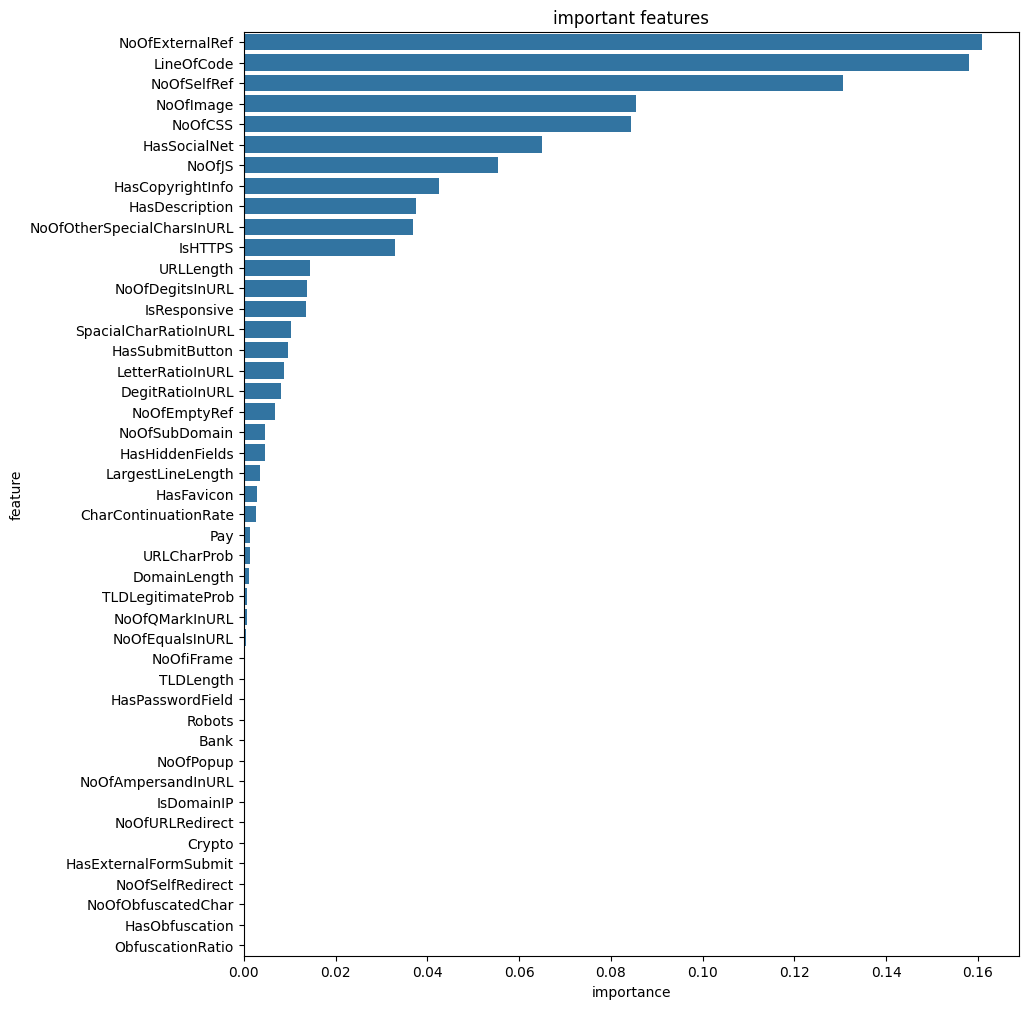

In [21]:
#feature importance
important_feature = pd.DataFrame({
    "feature" : x_train.columns,
    "importance" : forest.feature_importances_

}
).sort_values("importance",ascending=False)
print(important_feature)

#visualization
plt.figure(figsize=(10,12))
sns.barplot(x = "importance",y = "feature",data = important_feature)
plt.xlabel("importance")
plt.ylabel("feature")
plt.title("important features")

In [22]:
#remove irrelevant dataset
threasold = 0.001
low_important_features = important_feature[important_feature["importance"] < threasold]["feature"].tolist()
print(low_important_features)

['TLDLegitimateProb', 'NoOfQMarkInURL', 'NoOfEqualsInURL', 'NoOfiFrame', 'TLDLength', 'HasPasswordField', 'Robots', 'Bank', 'NoOfPopup', 'NoOfAmpersandInURL', 'IsDomainIP', 'NoOfURLRedirect', 'Crypto', 'HasExternalFormSubmit', 'NoOfSelfRedirect', 'NoOfObfuscatedChar', 'HasObfuscation', 'ObfuscationRatio']


In [23]:
print(df['TLDLegitimateProb'].value_counts().head(10))
print(df['TLDLegitimateProb'].nunique())

TLDLegitimateProb
0.522907    112554
0.079963     18793
0.038420      7097
0.001502      6508
0.028555      6395
0.005977      5422
0.012927      4201
0.032650      3996
0.018013      3875
0.010086      2979
Name: count, dtype: int64
465


In [24]:
x_final = x.drop(columns=low_important_features)

print(f"before: {x.shape[1]} features")
print(f"after:  {x_final.shape[1]} features")

# Final Train-Test split
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    x_final, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Final Model
forest_final = RandomForestClassifier(
    n_estimators=101,
    max_depth=25,
    min_samples_leaf=30,
    min_samples_split=50,
    random_state=42,
    n_jobs=-1
)

forest_final.fit(X_train_f, y_train_f)

y_train_pred_f = forest_final.predict(X_train_f)
y_pred_f = forest_final.predict(X_test_f)

print("Train accuracy:", accuracy_score(y_train_f, y_train_pred_f))
print("Test accuracy:", accuracy_score(y_test_f, y_pred_f))
print(classification_report(y_test_f, y_pred_f))

before: 45 features
after:  27 features
Train accuracy: 0.9997296380330372
Test accuracy: 0.999597107657075
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [25]:
x_final.columns

Index(['URLLength', 'DomainLength', 'CharContinuationRate', 'URLCharProb',
       'NoOfSubDomain', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasFavicon', 'IsResponsive', 'HasDescription', 'HasSocialNet',
       'HasSubmitButton', 'HasHiddenFields', 'Pay', 'HasCopyrightInfo',
       'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef',
       'NoOfExternalRef'],
      dtype='object')

In [26]:
# save the modeland the final columns
import joblib
joblib.dump(forest_final,"phishing_detector.pkl")
joblib.dump(x_final.columns.tolist(),"features_name.pkl")

['features_name.pkl']

In [28]:
%pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   --- ------------------------------------ 4.7/48.9 MB 46.8 MB/s eta 0:00:01
   ------------------- -------------------- 24.1/48.9 MB 74.5 MB/s eta 0:00:01
   ------------------------------- -------- 39.1/48.9 MB 74.2 MB/s eta 0:00:01
   ---------------------------------------  48.8/48.9 MB 68.8 MB/s eta 0:00:01
   ---------------------------------------- 48.9/48.9 MB 64.4 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [29]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X = x_final
y = df_clean['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
import joblib

joblib.dump(xgb_model, 'model/xgb_phishing_detector.pkl')
print("XGBoost model saved!")

Test accuracy: 0.9999575902796921
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

XGBoost model saved!


In [30]:
x_final.columns

Index(['URLLength', 'DomainLength', 'CharContinuationRate', 'URLCharProb',
       'NoOfSubDomain', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasFavicon', 'IsResponsive', 'HasDescription', 'HasSocialNet',
       'HasSubmitButton', 'HasHiddenFields', 'Pay', 'HasCopyrightInfo',
       'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef',
       'NoOfExternalRef'],
      dtype='object')

In [31]:
# In dono ko drop karo
drop_extra = ['CharContinuationRate', 'URLCharProb']

X_final_v2 = x_final.drop(columns=drop_extra)
print(f"Features: {X_final_v2.shape[1]}")
print(X_final_v2.columns.tolist())

# Retrain karo
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_final_v2, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

xgb_v2 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_v2.fit(X_train_v2, y_train_v2)
y_pred_v2 = xgb_v2.predict(X_test_v2)
print("Accuracy:", accuracy_score(y_test_v2, y_pred_v2))

Features: 25
['URLLength', 'DomainLength', 'NoOfSubDomain', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasFavicon', 'IsResponsive', 'HasDescription', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'Pay', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']
Accuracy: 0.9999575902796921


In [32]:
import joblib

joblib.dump(xgb_v2, 'model/xgb_phishing_detector_v2.pkl')
joblib.dump(X_final_v2.columns.tolist(), 'model/feature_names_v2.pkl')

print("Model saved!")
print("Features:", X_final_v2.columns.tolist())

Model saved!
Features: ['URLLength', 'DomainLength', 'NoOfSubDomain', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasFavicon', 'IsResponsive', 'HasDescription', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'Pay', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']


In [33]:
# Stackoverflow ki values vs dataset comparison
test = pd.DataFrame([{
    "URLLength": 35,
    "DomainLength": 17,
    "NoOfSubDomain": 0,
    "LetterRatioInURL": 0.857,
    "NoOfDegitsInURL": 0,
    "DegitRatioInURL": 0,
    "NoOfOtherSpecialCharsInURL": 5,
    "SpacialCharRatioInURL": 0.142,
    "IsHTTPS": 1,
    "LineOfCode": 2909,
    "LargestLineLength": 80852,
    "HasFavicon": 1,
    "IsResponsive": 1,
    "HasDescription": 0,
    "HasSocialNet": 1,
    "HasSubmitButton": 1,
    "HasHiddenFields": 1,
    "Pay": 0,
    "HasCopyrightInfo": 1,
    "NoOfImage": 16,
    "NoOfCSS": 15,
    "NoOfJS": 64,
    "NoOfSelfRef": 147,
    "NoOfEmptyRef": 2,
    "NoOfExternalRef": 69
}])[X_final_v2.columns.tolist()]

legit_avg = df[df['label']==1][X_final_v2.columns.tolist()].mean()
phish_avg = df[df['label']==0][X_final_v2.columns.tolist()].mean()

print(f"{'Feature':<30} {'Stackoverflow':>13} {'Legit Avg':>10} {'Phish Avg':>10} {'Closer To':>12}")
print("-"*80)
for col in X_final_v2.columns.tolist():
    val = test[col].values[0]
    l_avg = legit_avg[col]
    p_avg = phish_avg[col]
    closer = "✅ Legit" if abs(val-l_avg) < abs(val-p_avg) else "🚨 Phish"
    print(f"{col:<30} {val:>13.3f} {l_avg:>10.3f} {p_avg:>10.3f} {closer:>12}")

Feature                        Stackoverflow  Legit Avg  Phish Avg    Closer To
--------------------------------------------------------------------------------
URLLength                             35.000     26.229     45.720      ✅ Legit
DomainLength                          17.000     19.229     24.465      ✅ Legit
NoOfSubDomain                          0.000      1.162      1.169      ✅ Legit
LetterRatioInURL                       0.857      0.477      0.568      🚨 Phish
NoOfDegitsInURL                        0.000      0.051      4.326      ✅ Legit
DegitRatioInURL                        0.000      0.002      0.064      ✅ Legit
NoOfOtherSpecialCharsInURL             5.000      1.245      3.803      🚨 Phish
SpacialCharRatioInURL                  0.142      0.048      0.083      🚨 Phish
IsHTTPS                                1.000      1.000      0.492      ✅ Legit
LineOfCode                          2909.000   1947.492     65.730      ✅ Legit
LargestLineLength                  8085

In [34]:
# Yeh features problematic hain deployment mein
drop_deployment = [
    'LetterRatioInURL',   # URL length dependent
    'LargestLineLength',  # Inconsistent
    'NoOfImage',          # Site type dependent
    'NoOfEmptyRef',       # Minimal impact
    'Pay'                 # False negatives
]

X_final_v3 = X_final_v2.drop(columns=drop_deployment)
print(f"Features: {X_final_v3.shape[1]}")
print(X_final_v3.columns.tolist())

# Retrain
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_final_v3, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

xgb_v3 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_v3.fit(X_train_v3, y_train_v3)
y_pred_v3 = xgb_v3.predict(X_test_v3)
print("Accuracy:", accuracy_score(y_test_v3, y_pred_v3))

Features: 20
['URLLength', 'DomainLength', 'NoOfSubDomain', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'HasFavicon', 'IsResponsive', 'HasDescription', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasCopyrightInfo', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfExternalRef']
Accuracy: 0.9998303611187684


In [35]:
joblib.dump(xgb_v3, 'model/xgb_phishing_detector_v3.pkl')
joblib.dump(X_final_v3.columns.tolist(), 'model/feature_names_v3.pkl')

def predict_v3(url: str, js_features: dict) -> None:
    xgb = joblib.load('model/xgb_phishing_detector_v3.pkl')
    feature_names = joblib.load('model/feature_names_v3.pkl')
    
    df_pred = pd.DataFrame([js_features])[feature_names]
    probability = xgb.predict_proba(df_pred)[0]
    
    phishing_prob = probability[0]
    legit_prob = probability[1]
    
    if phishing_prob > 0.60:
        prediction = "🚨 Phishing"
        confidence = phishing_prob * 100
    else:
        prediction = "✅ Legitimate"
        confidence = legit_prob * 100
    
    print(f"URL: {url}")
    print(f"Prediction: {prediction}")
    print(f"Confidence: {confidence:.2f}%")
    print("-"*40)

# Stackoverflow
predict_v3(
    "https://stackoverflow.com",
    {"URLLength":35,"DomainLength":17,"NoOfSubDomain":0,
     "NoOfDegitsInURL":0,"DegitRatioInURL":0,
     "NoOfOtherSpecialCharsInURL":5,"SpacialCharRatioInURL":0.142,
     "IsHTTPS":1,"LineOfCode":2909,
     "HasFavicon":1,"IsResponsive":1,"HasDescription":0,
     "HasSocialNet":1,"HasSubmitButton":1,"HasHiddenFields":1,
     "HasCopyrightInfo":1,"NoOfCSS":15,"NoOfJS":64,
     "NoOfSelfRef":147,"NoOfExternalRef":69}
)

# Wikipedia
predict_v3(
    "https://wikipedia.org",
    {"URLLength":26,"DomainLength":17,"NoOfSubDomain":1,
     "NoOfDegitsInURL":0,"DegitRatioInURL":0,
     "NoOfOtherSpecialCharsInURL":6,"SpacialCharRatioInURL":0.230,
     "IsHTTPS":1,"LineOfCode":968,
     "HasFavicon":1,"IsResponsive":1,"HasDescription":1,
     "HasSocialNet":0,"HasSubmitButton":1,"HasHiddenFields":1,
     "HasCopyrightInfo":0,"NoOfCSS":3,"NoOfJS":4,
     "NoOfSelfRef":366,"NoOfExternalRef":8}
)

URL: https://stackoverflow.com
Prediction: 🚨 Phishing
Confidence: 93.88%
----------------------------------------
URL: https://wikipedia.org
Prediction: ✅ Legitimate
Confidence: 97.91%
----------------------------------------


In [40]:
# Base features
base = {
    "URLLength":35,"DomainLength":17,"NoOfSubDomain":0,
    "NoOfDegitsInURL":0,"DegitRatioInURL":0,
    "NoOfOtherSpecialCharsInURL":5,"SpacialCharRatioInURL":0.142,
    "IsHTTPS":1,"LineOfCode":3002,
    "HasFavicon":1,"IsResponsive":1,"HasDescription":1,
    "HasSocialNet":1,"HasSubmitButton":1,"HasHiddenFields":1,
    "HasCopyrightInfo":1,"NoOfCSS":14,"NoOfJS":70,
    "NoOfSelfRef":152,"NoOfExternalRef":71
}

# Ek ek feature ko dataset average se replace karo
legit_avg = df[df['label']==1][X_final_v3.columns.tolist()].mean()

for col in X_final_v3.columns.tolist():
    test = base.copy()
    test[col] = legit_avg[col]  # Dataset average se replace
    
    df_test = pd.DataFrame([test])[X_final_v3.columns.tolist()]
    prob = xgb_v3.predict_proba(df_test)[0]
    
    result = "✅ Legitimate" if prob[1] > 0.4 else "🚨 Phishing"
    print(f"{col:<35} → {result} ({max(prob)*100:.1f}%)")

URLLength                           → ✅ Legitimate (59.8%)
DomainLength                        → 🚨 Phishing (73.0%)
NoOfSubDomain                       → ✅ Legitimate (99.3%)
NoOfDegitsInURL                     → 🚨 Phishing (81.8%)
DegitRatioInURL                     → 🚨 Phishing (81.8%)
NoOfOtherSpecialCharsInURL          → 🚨 Phishing (89.7%)
SpacialCharRatioInURL               → 🚨 Phishing (72.0%)
IsHTTPS                             → 🚨 Phishing (81.8%)
LineOfCode                          → 🚨 Phishing (81.8%)
HasFavicon                          → 🚨 Phishing (87.8%)
IsResponsive                        → 🚨 Phishing (89.7%)
HasDescription                      → 🚨 Phishing (93.9%)
HasSocialNet                        → 🚨 Phishing (97.0%)
HasSubmitButton                     → 🚨 Phishing (78.6%)
HasHiddenFields                     → 🚨 Phishing (79.6%)
HasCopyrightInfo                    → 🚨 Phishing (83.3%)
NoOfCSS                             → 🚨 Phishing (81.8%)
NoOfJS                     

In [41]:
# Dono ek saath fix karo
test = base.copy()
test['URLLength'] = legit_avg['URLLength']
test['NoOfSubDomain'] = legit_avg['NoOfSubDomain']

df_test = pd.DataFrame([test])[X_final_v3.columns.tolist()]
prob = xgb_v3.predict_proba(df_test)[0]
print(f"Prediction: {'✅ Legitimate' if prob[1] > 0.4 else '🚨 Phishing'}")
print(f"Confidence: {max(prob)*100:.2f}%")

Prediction: ✅ Legitimate
Confidence: 99.81%


In [42]:
drop_v4 = ['URLLength', 'NoOfSubDomain']

X_final_v4 = X_final_v3.drop(columns=drop_v4)
print(f"Features: {X_final_v4.shape[1]}")
print(X_final_v4.columns.tolist())

X_train_v4, X_test_v4, y_train_v4, y_test_v4 = train_test_split(
    X_final_v4, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

xgb_v4 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_v4.fit(X_train_v4, y_train_v4)
y_pred_v4 = xgb_v4.predict(X_test_v4)
print("Accuracy:", accuracy_score(y_test_v4, y_pred_v4))

Features: 18
['DomainLength', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'HasFavicon', 'IsResponsive', 'HasDescription', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasCopyrightInfo', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfExternalRef']
Accuracy: 0.9994062639156894


In [46]:
# Pehle yeh run karo — model save karo
joblib.dump(xgb_v4, 'model/xgb_phishing_detector_v4.pkl')
joblib.dump(X_final_v4.columns.tolist(), 'model/feature_names_v4.pkl')

print("Saved!")
print("Features:", X_final_v4.columns.tolist())

Saved!
Features: ['DomainLength', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'HasFavicon', 'IsResponsive', 'HasDescription', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasCopyrightInfo', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfExternalRef']


In [48]:
joblib.dump(xgb_v4, 'model/xgb_phishing_detector_v4.pkl')
joblib.dump(X_final_v4.columns.tolist(), 'model/feature_names_v4.pkl')

def predict_v4(url: str, js_features: dict) -> None:
    xgb = joblib.load('model/xgb_phishing_detector_v4.pkl')
    feature_names = joblib.load('model/feature_names_v4.pkl')
    
    df_pred = pd.DataFrame([js_features])[feature_names]
    probability = xgb.predict_proba(df_pred)[0]
    
    phishing_prob = probability[0]
    legit_prob = probability[1]
    
    if phishing_prob > 0.60:
        prediction = "🚨 Phishing"
        confidence = phishing_prob * 100
    else:
        prediction = "✅ Legitimate"
        confidence = legit_prob * 100
    
    print(f"URL: {url}")
    print(f"Prediction: {prediction}")
    print(f"Confidence: {confidence:.2f}%")
    print("-"*40)

# ← Yeh add karo — function call!
predict_v4(
    "https://stackoverflow.com",
    {"DomainLength":17,"NoOfDegitsInURL":0,"DegitRatioInURL":0,
     "NoOfOtherSpecialCharsInURL":5,"SpacialCharRatioInURL":0.142,
     "IsHTTPS":1,"LineOfCode":3002,"HasFavicon":1,"IsResponsive":1,
     "HasDescription":1,"HasSocialNet":1,"HasSubmitButton":1,
     "HasHiddenFields":1,"HasCopyrightInfo":1,"NoOfCSS":14,
     "NoOfJS":70,"NoOfSelfRef":152,"NoOfExternalRef":71}
)

predict_v4(
    "https://wikipedia.org",
    {"DomainLength":17,"NoOfDegitsInURL":0,"DegitRatioInURL":0,
     "NoOfOtherSpecialCharsInURL":6,"SpacialCharRatioInURL":0.230,
     "IsHTTPS":1,"LineOfCode":968,"HasFavicon":1,"IsResponsive":1,
     "HasDescription":1,"HasSocialNet":0,"HasSubmitButton":1,
     "HasHiddenFields":1,"HasCopyrightInfo":0,"NoOfCSS":3,
     "NoOfJS":4,"NoOfSelfRef":366,"NoOfExternalRef":8}
)

URL: https://stackoverflow.com
Prediction: ✅ Legitimate
Confidence: 95.53%
----------------------------------------
URL: https://wikipedia.org
Prediction: ✅ Legitimate
Confidence: 84.10%
----------------------------------------


In [50]:
# Dataset se 5 phishing sites nikalo
phish_samples = df[df['label'] == 0][['URL'] + X_final_v4.columns.tolist()].head(5)

print("=== Phishing Sites Test ===")
for _, row in phish_samples.iterrows():
    features = row[X_final_v4.columns.tolist()].to_dict()
    url = row['URL']
    
    df_pred = pd.DataFrame([features])[X_final_v4.columns.tolist()]
    prob = xgb_v4.predict_proba(df_pred)[0]
    
    phishing_prob = prob[0]
    legit_prob = prob[1]
    
    if phishing_prob > 0.60:
        prediction = "🚨 Phishing"
        confidence = phishing_prob * 100
    else:
        prediction = "✅ Legitimate"
        confidence = legit_prob * 100
    
    print(f"URL: {url}")
    print(f"Prediction: {prediction} ({confidence:.2f}%)")
    print("-"*40)

=== Phishing Sites Test ===
URL: http://www.teramill.com
Prediction: 🚨 Phishing (100.00%)
----------------------------------------
URL: http://www.f0519141.xsph.ru
Prediction: 🚨 Phishing (100.00%)
----------------------------------------
URL: http://www.shprakserf.gq
Prediction: 🚨 Phishing (100.00%)
----------------------------------------
URL: https://service-mitld.firebaseapp.com/
Prediction: 🚨 Phishing (100.00%)
----------------------------------------
URL: http://www.kuradox92.lima-city.de
Prediction: 🚨 Phishing (100.00%)
----------------------------------------


In [ ]:
# Dono ek saath fix karo
test = base.copy()
test['URLLength'] = legit_avg['URLLength']
test['NoOfSubDomain'] = legit_avg['NoOfSubDomain']

df_test = pd.DataFrame([test])[X_final_v3.columns.tolist()]
prob = xgb_v3.predict_proba(df_test)[0]
print(f"Prediction: {'✅ Legitimate' if prob[1] > 0.4 else '🚨 Phishing'}")
print(f"Confidence: {max(prob)*100:.2f}%")

Prediction: ✅ Legitimate
Confidence: 99.81%


In [52]:
predict_v4(
    "https://www.github.com",
    {"DomainLength":10,"NoOfDegitsInURL":0,"DegitRatioInURL":0,
     "NoOfOtherSpecialCharsInURL":5,"SpacialCharRatioInURL":0.263,
     "IsHTTPS":1,"LineOfCode":4262,"HasFavicon":1,"IsResponsive":1,
     "HasDescription":1,"HasSocialNet":0,"HasSubmitButton":1,
     "HasHiddenFields":1,"HasCopyrightInfo":1,"NoOfCSS":58,
     "NoOfJS":10,"NoOfSelfRef":71,"NoOfExternalRef":9}
)

URL: https://www.github.com
Prediction: 🚨 Phishing
Confidence: 74.66%
----------------------------------------
